In [5]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   -- ------------------------------------- 7.3/113.7 MB 36.0 MB/s eta 0:00:03
   ----- ---------------------------------- 16.3/113.7 MB 38.7 MB/s eta 0:00:03
   --------- ------------------------------ 26.5/113.7 MB 42.0 MB/s eta 0:00:03
   ------------- -------------------------- 37.2/113.7 MB 44.1 MB/s eta 0:00:02
   ---------------- ----------------------- 48.0/113.7 MB 45.3 MB/s eta 0:00:02
   -------------------- ------------------- 57.7/113.7 MB 45.3 MB/s eta 0:00:02
   ------------------------ --------------- 68.4/113.7 MB 46.0 MB/s eta 0:00:01
   --------------------------- ------------ 79.4/113.7 MB 46.7 MB/s eta 0:00:01
   ------------------------------- -------- 89.7/113.7 MB 47.1 MB/s eta 0:00:01
   ---------------------------------- ----- 98.8/113.7 MB 47.0 MB/s eta 0:0

In [7]:
%pip install scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------- ----- 6.8/8.0 MB 35.1 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 33.8 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------------------------- ---------- 6.0/8.1 MB 28.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 27.7 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 30.7 MB/s  0:00:00
Using cached joblib-1.5.

# Grupo N.º 2  
## Trabajo Grupal 3  
 ### Integrantes:
 - Héctor Ramos Vera 
 - David Sebastian Leon Guaman
 - Polk Brando Vernaza Quiñonez
 


### Análisis de Datos: Monitoreo de Pacientes en UCI y Predicción de Mortalidad (15 000 registros)
- El propósito de este conjunto de datos, centrado en el Análisis de Datos: Monitoreo de Pacientes en UCI y Predicción de Mortalidad, es proporcionar una base sólida para mejorar la toma de decisiones críticas en entornos hospitalarios mediante el uso de inteligencia de datos

### Instalación y configuración de Kaggle para la descarga del dataset

In [ ]:
%pip install kaggle

Defaulting to user installation because normal site-packages is not writeable


- Descagar el dataset de de forma remota

In [2]:
!kaggle datasets download jayjoshi37/icu-patient-monitoring-and-mortality-prediction

Dataset URL: https://www.kaggle.com/datasets/jayjoshi37/icu-patient-monitoring-and-mortality-prediction
License(s): CC0-1.0
icu-patient-monitoring-and-mortality-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


## 1 Selección del dataset -
- Descromprimir el archivo zip

In [3]:
import zipfile
with zipfile.ZipFile("icu-patient-monitoring-and-mortality-prediction.zip", 'r') as zip_ref:
    zip_ref.extractall("icu_dataset")

- Importar las librerias 

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

- Instalación de la librería KaggleHub

In [9]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
Using cached kagglehub-1.0.0-py3-none-any.whl (70 kB)

   ---------------------------------------- 0/2 [pyyaml]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [10]:
%pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

c:\Users\POLK\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- Carga del dataset en un DataFrame

In [13]:
df=pd.read_csv('icu_dataset/ICU_Patient_Monitoring_Mortality_Prediction_15000.csv')

In [ ]:
df

,patient_id,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,PAT000001,32,Male,Urgent,3.75,136.06,19.64,162.01,127.16,104.04,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,PAT000002,46,Male,Urgent,2.91,108.95,7.79,124.18,94.79,131.05,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,PAT000003,87,Male,Urgent,6.84,95.21,7.44,117.54,89.35,171.84,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1
3,PAT000004,21,Male,Emergency,1.96,63.62,11.51,82.22,51.84,164.59,...,214.40,1.06,4940.99,1,0,1.16,33.54,14.14,0,1
4,PAT000005,21,Male,Urgent,7.71,65.92,12.17,74.98,39.34,146.10,...,201.33,5.28,4492.46,0,0,21.68,31.63,11.23,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PAT014996,27,Female,Elective,0.02,100.21,15.97,105.34,79.25,123.65,...,217.13,3.22,1034.24,1,0,13.41,13.89,8.30,0,0
14996,PAT014997,68,Male,Emergency,8.39,88.72,13.34,100.69,77.45,148.53,...,171.81,5.17,989.13,0,1,14.36,38.71,1.03,0,0
14997,PAT014998,24,Female,Elective,9.06,83.32,23.45,109.28,56.80,133.29,...,201.38,2.23,3007.17,0,1,18.94,19.35,12.90,1,0
14998,PAT014999,82,Female,Emergency,3.60,86.64,23.59,95.87,67.42,137.37,...,203.62,2.99,1402.62,0,1,17.93,38.89,12.27,0,0


- Identificación de valores únicos en la variable de mortalidad

In [14]:
df['mortality_label'].unique()

array([0, 1])

- Distribución de la variable de mortalidad

In [15]:
df.groupby('mortality_label').size()

mortality_label
0    11582
1     3418
dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             15000 non-null  str    
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  str    
 3   admission_type         15000 non-null  str    
 4   comorbidity_score      15000 non-null  float64
 5   heart_rate_mean        15000 non-null  float64
 6   heart_rate_std         15000 non-null  float64
 7   heart_rate_max         15000 non-null  float64
 8   heart_rate_min         15000 non-null  float64
 9   systolic_bp_mean       15000 non-null  float64
 10  systolic_bp_std        15000 non-null  float64
 11  respiratory_rate_mean  15000 non-null  float64
 12  spo2_mean              15000 non-null  float64
 13  temperature_mean       15000 non-null  float64
 14  glucose_mean           15000 non-null  float64
 15  lactate_mean 

### 2  Procesamiento de datos 
- Limpieza y Transformación de Datos


In [17]:
if df ['mortality_label'].dtype == 'object':
  le = LabelEncoder()
  df['mortality_label'] = le.fit_transform(df['mortality_label'])

  df = pd.get_dummies(df)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             15000 non-null  str    
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  str    
 3   admission_type         15000 non-null  str    
 4   comorbidity_score      15000 non-null  float64
 5   heart_rate_mean        15000 non-null  float64
 6   heart_rate_std         15000 non-null  float64
 7   heart_rate_max         15000 non-null  float64
 8   heart_rate_min         15000 non-null  float64
 9   systolic_bp_mean       15000 non-null  float64
 10  systolic_bp_std        15000 non-null  float64
 11  respiratory_rate_mean  15000 non-null  float64
 12  spo2_mean              15000 non-null  float64
 13  temperature_mean       15000 non-null  float64
 14  glucose_mean           15000 non-null  float64
 15  lactate_mean 

- Detección y reporte de valores nulos

In [19]:
nulls   = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': null_pct})
null_report = null_report[null_report['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

print(f'Columnas con valores nulos: {len(null_report)} de {df.shape[1]}')
display(null_report if not null_report.empty else 'Sin valores nulos')

Columnas con valores nulos: 0 de 24


'Sin valores nulos'

- Separar columnas numéricas y categóricas 

In [20]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'\nColumnas numéricas  : {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')

if num_cols:
    imp_num = SimpleImputer(strategy='median')
    df[num_cols] = imp_num.fit_transform(df[num_cols])

if cat_cols:
    imp_cat = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = imp_cat.fit_transform(df[cat_cols])

print('\n Imputación completada (mediana para numéricas, moda para categóricas).')


Columnas numéricas  : 21
Columnas categóricas: 3

 Imputación completada (mediana para numéricas, moda para categóricas).


C:\Users\DAVID\AppData\Local\Temp\ipykernel_20392\4246366318.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


- Eliminar duplicados

In [21]:
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f' Duplicados eliminados: {n_before - len(df)}')

 Duplicados eliminados: 0


- Identificación de valores atípicos usando el rango intercuartílico (IQR)

In [22]:
outlier_report = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outlier_report[col] = n_out

outlier_df = pd.DataFrame.from_dict(outlier_report, orient='index', columns=['Outliers (IQR)'])
print(f'\nColumnas con outliers detectados: {len(outlier_df)}')
display(outlier_df.sort_values('Outliers (IQR)', ascending=False).head(10))


Columnas con outliers detectados: 3


,Outliers (IQR)
vasopressor_used,3677
mortality_label,3418
sepsis_flag,3029


- Detección automática de la columna objetivo (mortalidad)

In [23]:
TARGET_CANDIDATES = [
    'mortality', 'death', 'survived', 'outcome', 'hospital_death',
    'in_hospital_death', 'mortality_flag', 'deceased'
]
target_col = None
for c in df.columns:
    if c.lower().replace(' ', '_') in TARGET_CANDIDATES:
        target_col = c
        break

- primera columna binaria encontrada al final del df

In [24]:
if target_col is None:
    for c in reversed(df.columns):
        if df[c].nunique() == 2:
            target_col = c
            break

if target_col:
    print(f'\n Columna objetivo detectada: "{target_col}"')
    print(df[target_col].value_counts().rename_axis('Clase').reset_index(name='Conteo').to_string(index=False))
else:
    print('\n No se detectó columna objetivo binaria. Ajusta target_col manualmente.')


 Columna objetivo detectada: "mortality_label"
 Clase  Conteo
   0.0   11582
   1.0    3418


- Codificación de categóricas para ML

In [25]:
df_ml = df.copy()
le    = LabelEncoder()
for col in cat_cols:
    if col != target_col:
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print(f'\n Limpieza y transformación completadas. Shape final: {df.shape}')


 Limpieza y transformación completadas. Shape final: (15000, 24)


## 4. Análisis Exploratorio de Datos (EDA) </a>

El EDA responde tres preguntas clave:

1. **¿Cómo se distribuye la mortalidad?** → Tasa global y balance de clases.
2. **¿Qué variables numéricas difieren más entre pacientes que sobrevivieron y los que fallecieron?** → Análisis de medias por grupo.
3. **¿Qué variables están más correlacionadas con la mortalidad?** → Top correlaciones.

Estos hallazgos guiarán tanto las visualizaciones como la selección de features para el modelo.

- Tasa de mortalidad global

In [26]:
if target_col:
    mortality_rate = df[target_col].mean() * 100
    print(f'Tasa de mortalidad global : {mortality_rate:.2f}%')
    print(f'Pacientes totales         : {len(df):,}')
    print(f'Fallecidos                : {int(df[target_col].sum()):,}')
    print(f'Sobrevivientes            : {int((df[target_col] == 0).sum()):,}')

Tasa de mortalidad global : 22.79%
Pacientes totales         : 15,000
Fallecidos                : 3,418
Sobrevivientes            : 11,582


- Estadísticas por grupo (fallecido vs sobreviviente)

In [27]:
if target_col:
    print('\n── Medias por grupo (Fallecido=1 vs Sobreviviente=0) ──')
    group_stats = df.groupby(target_col)[num_cols].mean().round(3).T
    group_stats.columns = ['Sobrevivió (0)', 'Falleció (1)']
    group_stats['Diferencia %'] = (
        (group_stats['Falleció (1)'] - group_stats['Sobrevivió (0)'])
        / group_stats['Sobrevivió (0)'].replace(0, np.nan) * 100
    ).round(1)
    display(group_stats.sort_values('Diferencia %', key=abs, ascending=False).head(15))


── Medias por grupo (Fallecido=1 vs Sobreviviente=0) ──


,Sobrevivió (0),Falleció (1),Diferencia %
vasopressor_used,0.221,0.328,48.4
sepsis_flag,0.182,0.270,48.4
ventilation_required,0.274,0.398,45.3
comorbidity_score,4.889,5.328,9.0
sofa_score,9.785,10.650,8.8
apache_score,22.139,23.709,7.1
age,53.317,56.260,5.5
systolic_bp_mean,135.016,133.982,-0.8
length_of_stay_days,15.456,15.353,-0.7
glucose_mean,158.910,159.811,0.6


- Top correlaciones con la variable objetivo 

In [28]:
if target_col and target_col in num_cols:
    correlaciones = df[num_cols].corr()[target_col].drop(target_col)
    top_corr = correlaciones.abs().sort_values(ascending=False).head(12)
    print('\n── Top 12 variables más correlacionadas con la mortalidad ──')
    corr_df = pd.DataFrame({
        'Variable': top_corr.index,
        'Correlación (|r|)': top_corr.values,
        'Dirección': ['Positiva' if correlaciones[v] > 0 else 'Negativa' for v in top_corr.index]
    })
    display(corr_df)


── Top 12 variables más correlacionadas con la mortalidad ──


,Variable,Correlación (|r|),Dirección
0,ventilation_required,0.113897,Positiva
1,vasopressor_used,0.104242,Positiva
2,sepsis_flag,0.092561,Positiva
3,apache_score,0.065262,Positiva
4,comorbidity_score,0.063640,Positiva
5,sofa_score,0.063130,Positiva
6,age,0.058697,Positiva
7,systolic_bp_mean,0.016689,Negativa
8,respiratory_rate_mean,0.008570,Negativa
9,systolic_bp_std,0.007903,Positiva


- Instalar libreria seaborn y matplotlib

In [29]:
%pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


- Importar librerias

## 5 Visualización de Datos
- Gráficos estáticos (matplotlib / seaborn)

C:\Users\DAVID\AppData\Local\Temp\ipykernel_20392\1551527600.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])


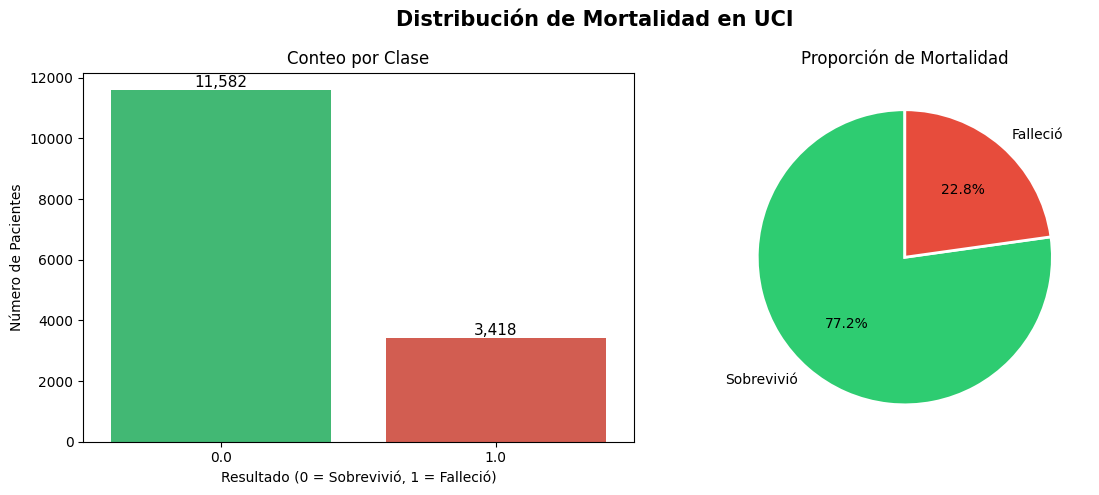

 Gráfico 1 guardado en la carpeta: graficos


In [30]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

OUT_STATIC = "graficos"  
os.makedirs(OUT_STATIC, exist_ok=True)  

if target_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Distribución de Mortalidad en UCI', fontsize=15, fontweight='bold')

    counts = df[target_col].value_counts().sort_index()
    labels = ['Sobrevivió', 'Falleció']

    sns.countplot(x=target_col, data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
    axes[0].set_title('Conteo por Clase')
    axes[0].set_xlabel('Resultado (0 = Sobrevivió, 1 = Falleció)')
    axes[0].set_ylabel('Número de Pacientes')
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height()):,}',
                         (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontsize=11)

    
    axes[1].pie(counts.values, labels=labels,
                colors=['#2ecc71', '#e74c3c'],
                autopct='%1.1f%%', startangle=90,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('Proporción de Mortalidad')

    plt.tight_layout()
    
    plt.savefig(os.path.join(OUT_STATIC, '01_distribucion_mortalidad.png'), bbox_inches='tight')
    plt.show()
    print(' Gráfico 1 guardado en la carpeta:', OUT_STATIC)

- Distribuciones de variables numéricas clave

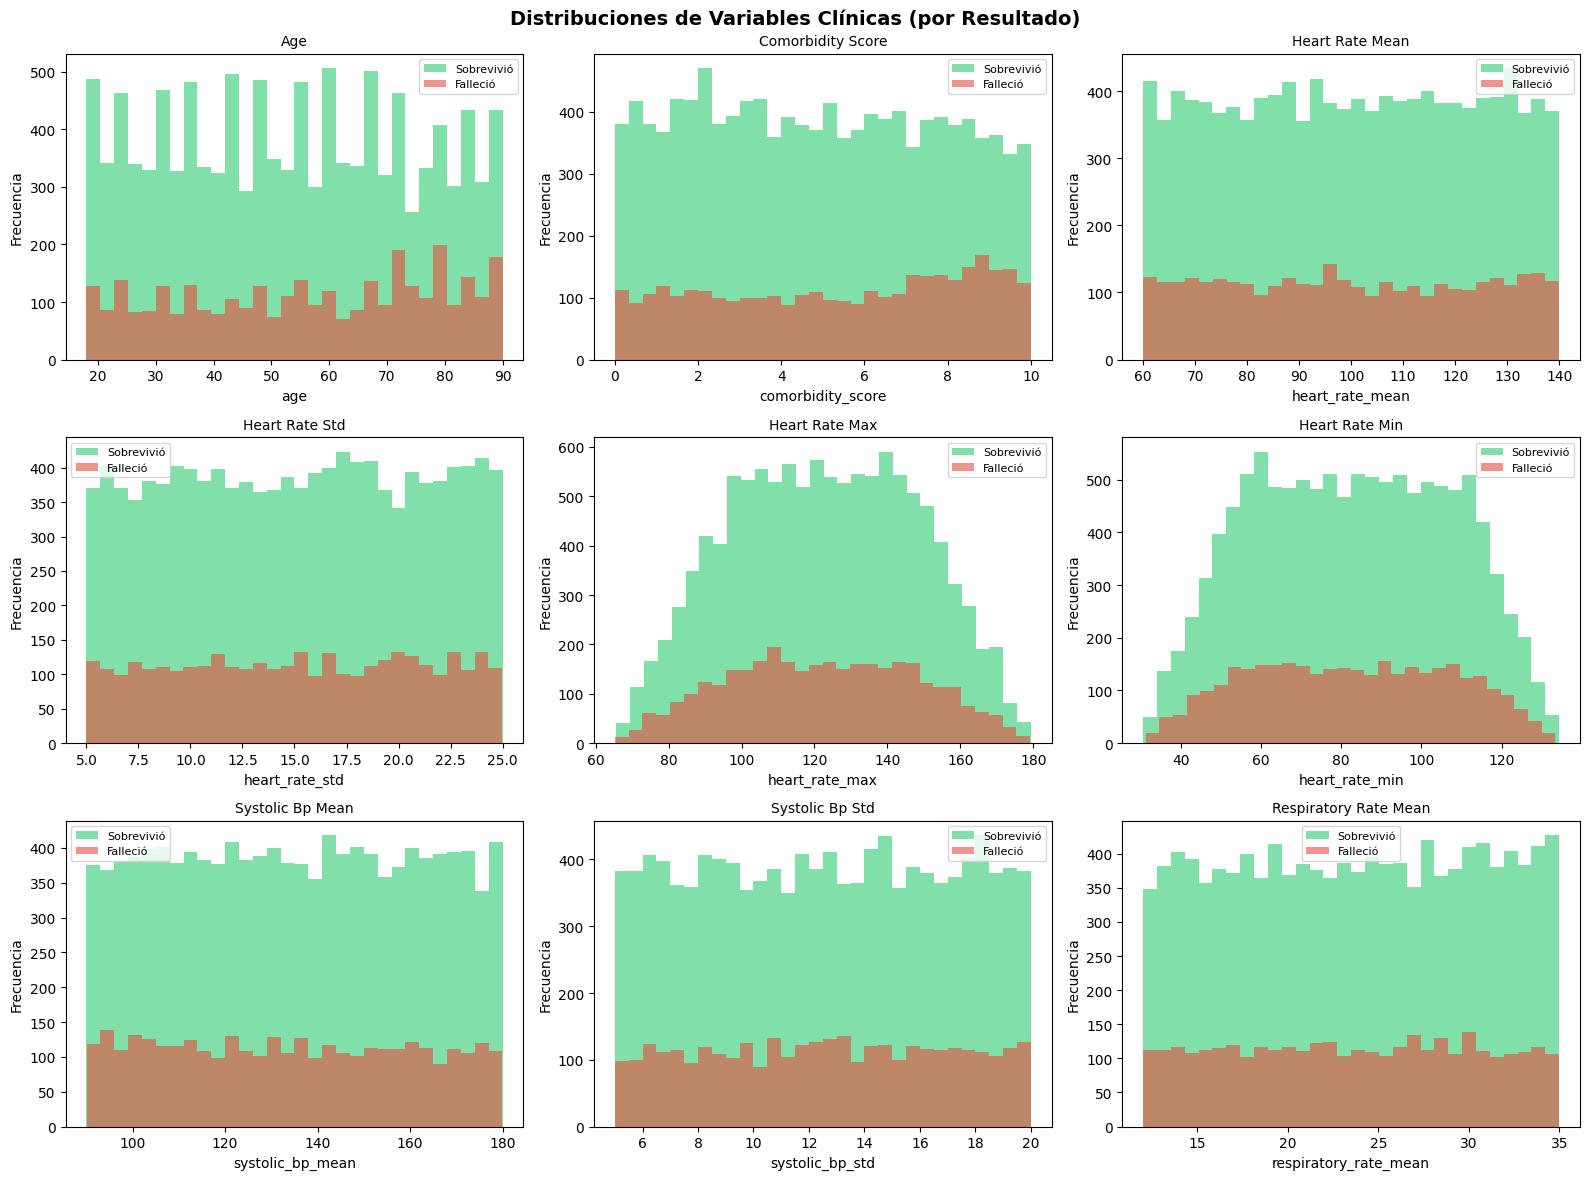

 Gráfico 2 guardado.


In [31]:
plot_cols = [c for c in num_cols if c != target_col][:9]

if plot_cols:
    n = len(plot_cols)
    cols_g = 3
    rows_g = (n + cols_g - 1) // cols_g
    fig, axes = plt.subplots(rows_g, cols_g, figsize=(16, rows_g * 4))
    axes = axes.flatten()
    fig.suptitle('Distribuciones de Variables Clínicas (por Resultado)', fontsize=14, fontweight='bold')

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        if target_col:
            for val, color, lbl in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Sobrevivió', 'Falleció']):
                subset = df[df[target_col] == val][col].dropna()
                ax.hist(subset, bins=30, alpha=0.6, color=color, label=lbl, edgecolor='none')
            ax.legend(fontsize=8)
        else:
            ax.hist(df[col].dropna(), bins=30, color='#3498db', alpha=0.8, edgecolor='none')
        ax.set_title(col.replace('_', ' ').title(), fontsize=10)
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{OUT_STATIC}/02_distribuciones_variables.png', bbox_inches='tight')
    plt.show()
    print(' Gráfico 2 guardado.')

- Mapa de calor de correlaciones

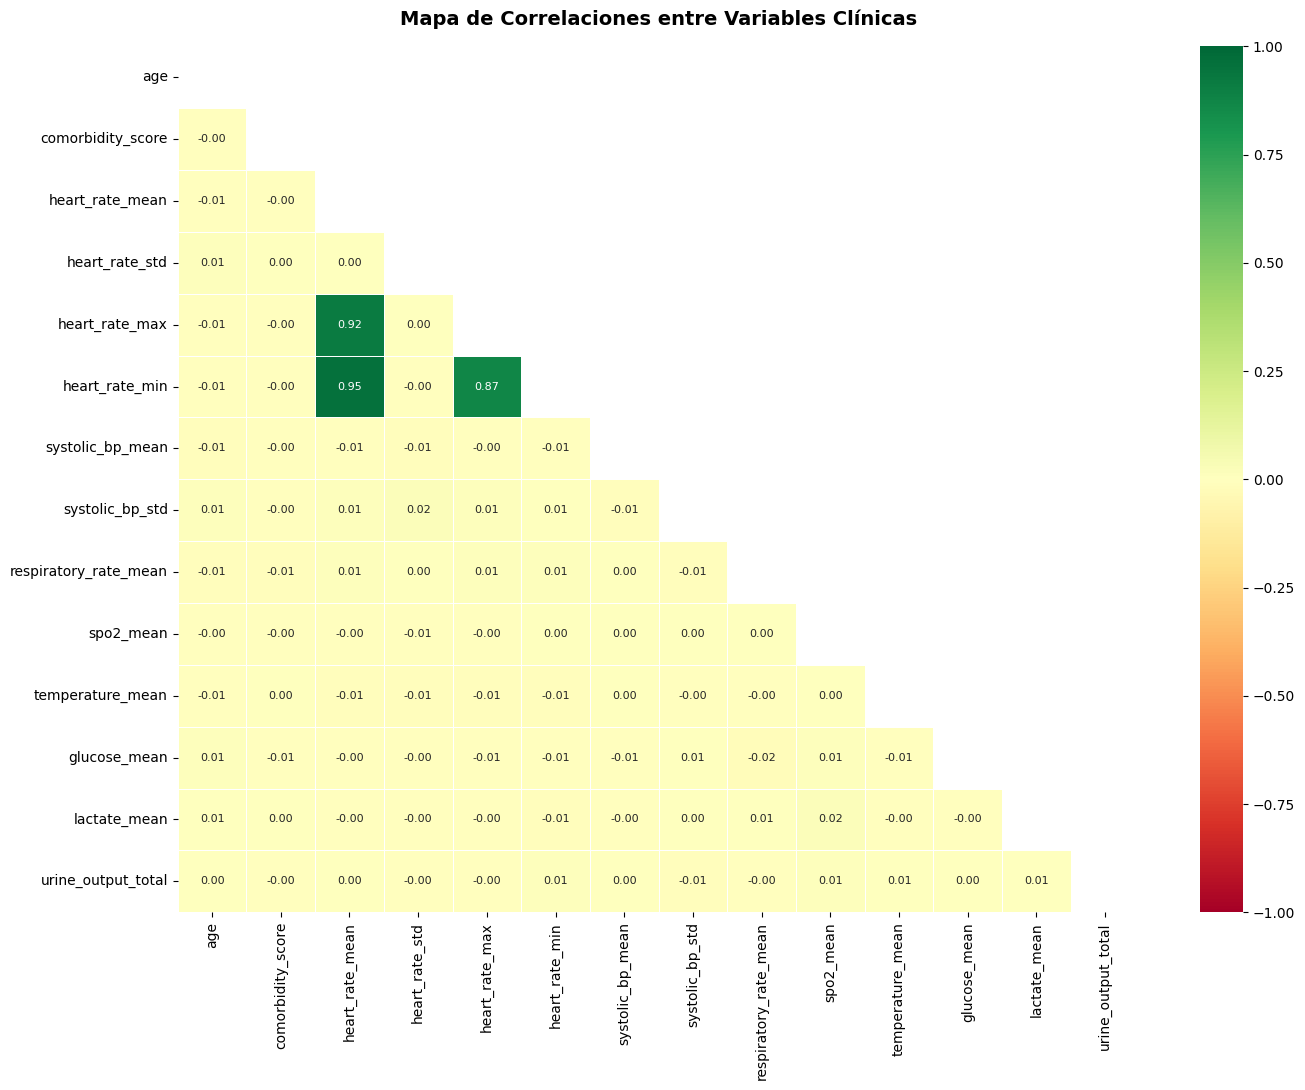

 Gráfico 3 guardado.


In [32]:
corr_cols = [c for c in num_cols][:14]

if len(corr_cols) >= 2:
    corr_matrix = df[corr_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f', linewidths=0.5,
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        annot_kws={'size': 8}, ax=ax
    )
    ax.set_title('Mapa de Correlaciones entre Variables Clínicas', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(f'{OUT_STATIC}/03_correlaciones_heatmap.png', bbox_inches='tight')
    plt.show()
    print(' Gráfico 3 guardado.')

- Boxplots por clase  

C:\Users\DAVID\AppData\Local\Temp\ipykernel_20392\2159125258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DAVID\AppData\Local\Temp\ipykernel_20392\2159125258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DAVID\AppData\Local\Temp\ipykernel_20392\2159125258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DAVID\AppData\Local\Temp\ipykernel_20392\2159125258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

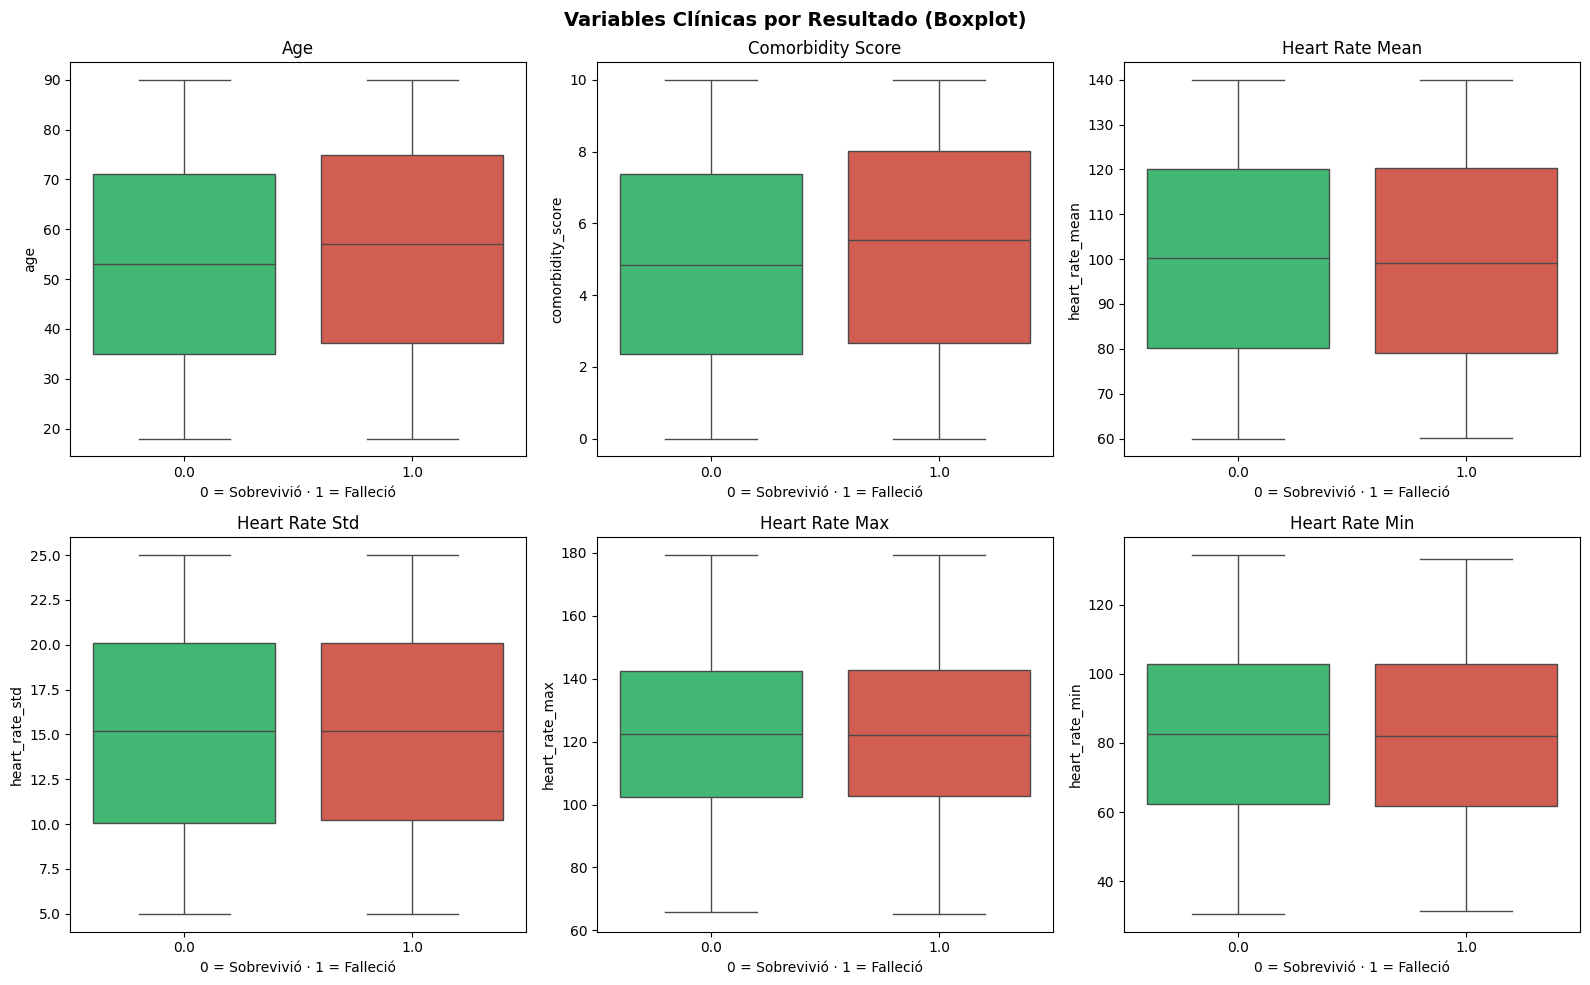

 Gráfico 4 guardado.


In [33]:
if target_col:
    box_cols = [c for c in num_cols if c != target_col][:6]
    if box_cols:
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        fig.suptitle('Variables Clínicas por Resultado (Boxplot)', fontsize=14, fontweight='bold')

        for i, col in enumerate(box_cols):
            sns.boxplot(
                x=target_col, y=col, data=df,
                palette=['#2ecc71', '#e74c3c'],
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
                ax=axes[i]
            )
            axes[i].set_title(col.replace('_', ' ').title())
            axes[i].set_xlabel('0 = Sobrevivió · 1 = Falleció')

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig(f'{OUT_STATIC}/04_boxplots_por_clase.png', bbox_inches='tight')
        plt.show()
        print(' Gráfico 4 guardado.')

- Variables categóricas vs mortalidad 

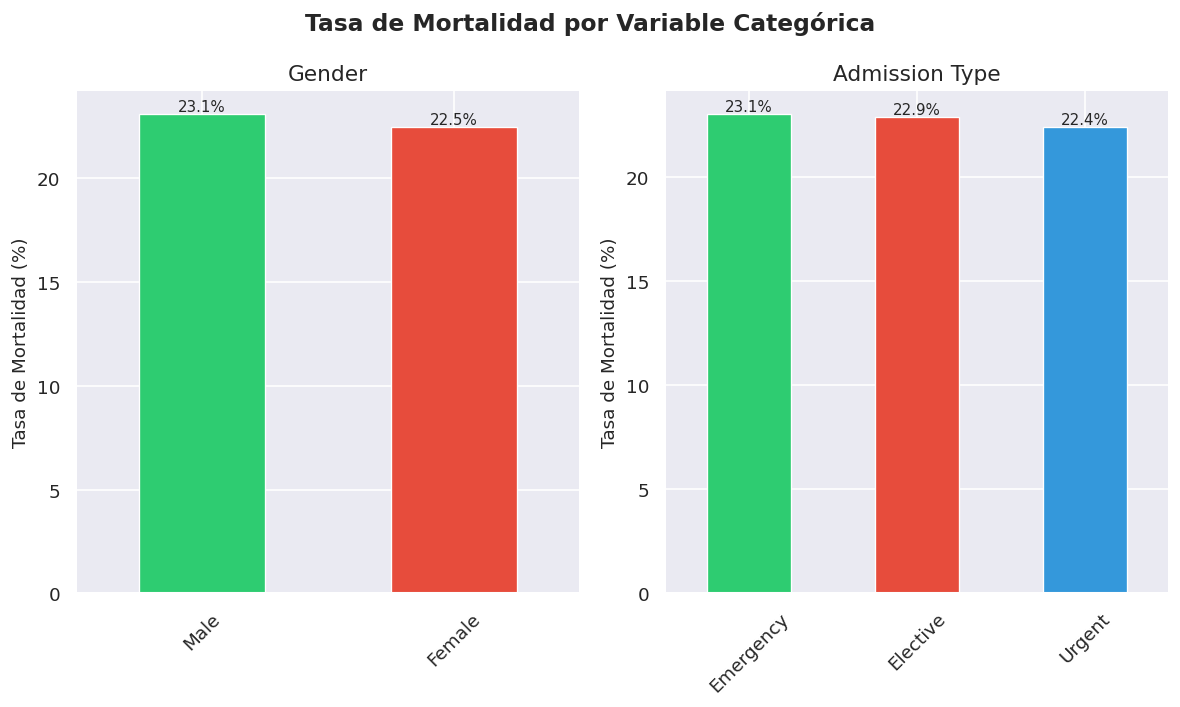

 Gráfico 5 guardado.


In [34]:
# Paleta de colores consistente en todo el notebook
PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
sns.set_theme(style='darkgrid', palette=PALETTE)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

cat_to_plot = [c for c in cat_cols if c != target_col and df[c].nunique() <= 10][:4]

if cat_to_plot and target_col:
    n = len(cat_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
    if n == 1:
        axes = [axes]
    fig.suptitle('Tasa de Mortalidad por Variable Categórica', fontsize=14, fontweight='bold')

    for i, col in enumerate(cat_to_plot):
        mortality_by_cat = df.groupby(col)[target_col].mean().sort_values(ascending=False) * 100
        mortality_by_cat.plot(kind='bar', ax=axes[i],
                               color=PALETTE[:len(mortality_by_cat)],
                               edgecolor='white', linewidth=0.8)
        axes[i].set_title(col.replace('_', ' ').title())
        axes[i].set_ylabel('Tasa de Mortalidad (%)')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        for bar in axes[i].patches:
            axes[i].annotate(f"{bar.get_height():.1f}%",
                             (bar.get_x() + bar.get_width()/2., bar.get_height()),
                             ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{OUT_STATIC}/05_mortalidad_por_categoria.png', bbox_inches='tight')
    plt.show()
    print(' Gráfico 5 guardado.')
else:
    print('(No hay variables categóricas con ≤10 categorías para graficar.)')

###  Selección aleatoria de registros
Esta instrucción realiza una selección aleatoria de índices dentro de un conjunto de datos almacenado en un *DataFrame*. Para ello utiliza la función sample del módulo random de la biblioteca estándar de Python.

In [35]:
indices = random.sample(range(len(df)), 5000)

In [36]:
df = df.sample(10000)

### Visualización de correlaciones en pacientes con mortalidad
 Este procedimiento genera una visualización de correlación entre variables del conjunto de datos utilizando herramientas de visualización de las bibliotecas Matplotlib y Seaborn. El objetivo es identificar relaciones estadísticas entre las variables en los registros asociados a mortalidad, permitiendo analizar posibles patrones clínicos o fisiológicos relevantes.

C:\Users\DAVID\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\DAVID\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


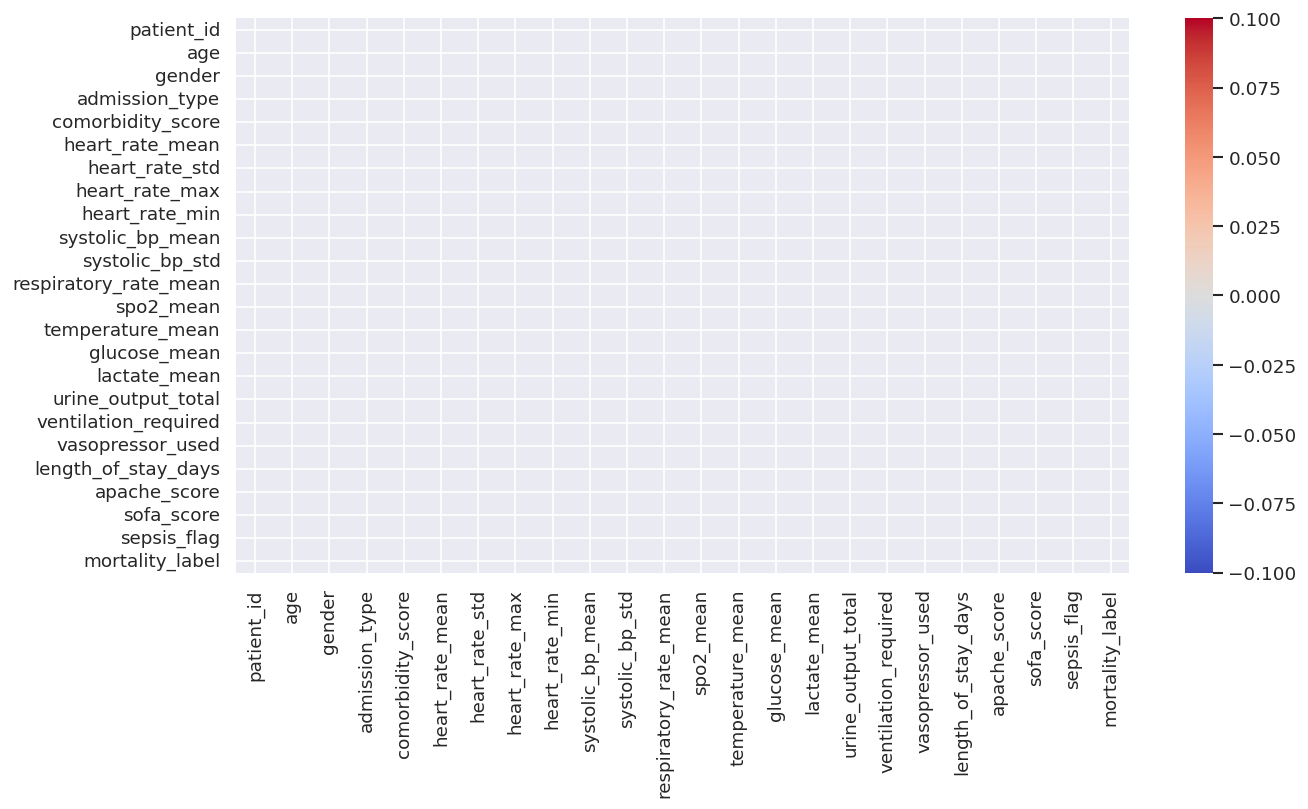

In [37]:
plt.figure(figsize=(12, 6))
sns.heatmap(df[df['respiratory_rate_mean'] == 1].corr(), cmap='coolwarm')
plt.show()